# Capstone: Define and Solve an ML Problem

In [1]:
import pandas as pd
import numpy as np
import os 
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, f1_score
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import OneHotEncoder 
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import tensorflow.keras as keras
from sklearn.preprocessing import StandardScaler
import time

**Note**: As you work through the notebook, you can import additional packages as needed.

## Overview


In this capstone assignment, you will follow the machine learning life cycle and implement one of the supervised learning models you have learned so far in this course, along with a neural network, to solve a predictive problem.

This capstone spans two lab sessions.

- **Unit 5 Lab:** You will define a machine learning problem, explore and prepare your data, and train, test, evaluate and improve a traditional machine learning model (Parts 1–5).
- **Unit 6 Lab:** After completing Unit 6 on neural networks, you will apply a neural network to the same problem and compare the two approaches (Parts 6–7).

There is a checkpoint at the end of Part 5 that marks where to stop during the Unit 5 lab.

You will complete the following:

1. Choose your Data Set and Build Your DataFrame
2. Define Your ML Problem
3. Understand Your Data
4. Prepare Your Data
5. Train, Test, Evaluate and Improve a Traditional Machine Learning Model *(Unit 5 lab)*
6. Train, Test, Evaluate and Improve Neural Network *(Unit 6 lab)*
7. Compare Your Models and Reflect *(Unit 6 lab)*

**This is an individual assignment.** You are welcome to discuss ideas with your peers, but the code and written responses you submit must be your own.

**Note:** This capstone is intentionally less scaffolded than your weekly labs; that is by design. You are expected to make your own implementation choices, add code cells as needed, and document your reasoning throughout.

## Part 1: Choose Your Data Set and Build Your DataFrame


You will choose one of two data sets to work with for this capstone. In both cases, you will be solving a supervised learning binary classification problem by predicting one of two possible class labels. Both data sets have been used earlier in the course, so you are already familiar with their structure. 

**Option A: Census Income Data** (`censusData.csv`)
This data set contains demographic and employment information from the 1994 U.S. Census. You will use it to predict whether an individual's annual income exceeds $50,000. Your label column is `income_binary`, which contains two values: `<=50K` and `>50K`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Option B: Airbnb NYC Listings Data** (`airbnbListingsData.csv`)
This data set contains information about Airbnb listings in New York City. You will use it to predict whether a listing is high-priced. The data set includes a new `price_category` column that classifies each listing as either "high price" or "low price" based on whether the listing’s price falls above or below the 75th percentile of all listing prices. Listings at or above the 75th percentile are labeled as `high`, while the remaining listings are labeled as `low`. You will need to convert this column into a binary numeric label (for example, 0 and 1) during data preparation.

**Note:**  These versions of the data sets differ slightly from the versions you have worked with in this program. For example, they may not include some of the preprocessing necessary for specific models. 

#### Load a Data Set and Save it as a Pandas DataFrame

The code cell below contains filenames (path + filename) for the two data sets available to you.

<b>Task:</b> In the code cell below, load your chosen data set using `pd.read_csv()` and save it to a DataFrame named `df`. Then call `df.head()` to inspect the first few row of the data set.

In [2]:
# File paths for both data sets
census_filename = os.path.join(os.getcwd(), "data_capstone", "censusData.csv")
airbnb_filename = os.path.join(os.getcwd(), "data_capstone", "airbnbListingsData.csv")

# Load your chosen dataset and save it to df
df = pd.read_csv(airbnb_filename)

df.head()

,name,description,neighborhood_overview,host_name,host_location,host_about,host_response_rate,host_acceptance_rate,host_is_superhost,host_listings_count,...,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications,price_category
0,Skylit Midtown Castle,"Beautiful, spacious skylit studio in the heart...",Centrally located in the heart of Manhattan ju...,Jennifer,"New York, New York, United States",A New Yorker since 2000! My passion is creatin...,0.80,0.17,True,8.0,...,4.86,4.41,False,3,3,0,0,0.33,9,low
1,"Whole flr w/private bdrm, bath & kitchen(pls r...","Enjoy 500 s.f. top floor in 1899 brownstone, w...",Just the right mix of urban center and local n...,LisaRoxanne,"New York, New York, United States",Laid-back Native New Yorker (formerly bi-coast...,0.09,0.69,True,1.0,...,4.71,4.64,False,1,1,0,0,4.86,6,low
2,"Spacious Brooklyn Duplex, Patio + Garden",We welcome you to stay in our lovely 2 br dupl...,NaN,Rebecca,"Brooklyn, New York, United States","Rebecca is an artist/designer, and Henoch is i...",1.00,0.25,True,1.0,...,4.50,5.00,False,1,1,0,0,0.02,3,high
3,Large Furnished Room Near B'way,Please don’t expect the luxury here just a bas...,"Theater district, many restaurants around here.",Shunichi,"New York, New York, United States",I used to work for a financial industry but no...,1.00,1.00,True,1.0,...,4.87,4.36,False,1,0,1,0,3.68,4,low
4,Cozy Clean Guest Room - Family Apt,"Our best guests are seeking a safe, clean, spa...",Our neighborhood is full of restaurants and ca...,MaryEllen,"New York, New York, United States",Welcome to family life with my oldest two away...,NaN,NaN,True,1.0,...,4.94,4.92,False,1,0,1,0,0.87,7,low


## Part 2: Define Your ML Problem

The first step of the machine learning life cycle involves defining your business problem. In the markdown cell below, you will clearly define what you are trying to predict and why it matters. 

<b>Task</b>: In the markdown cell below, answer all of the following questions:

1. Which data set did you choose?
2. What is your label? What are you predicting?
3. What features do you plan to use? (This list may change after you explore your data.)
5. Why does this problem matter? Using the business brief you read in the lab overview page, explain how the organization described there could use a model that predicts this label to create value or inform decisions for their client.

1. I chose Airbnb dataset
2. label: price_category
3. features: 'neighborhood_overview','accommodates','bathrooms','bedrooms','beds','amenities','price','review_scores_rating','review_scores_cleanliness'
4. Using ML solution to solve the classification problem improves efficiency and eventually profit Trove Analytics' client more compared to manually classifying. By training ML model to predict if a listing is high-priced, the company's client can save the client dozens of hours per month in manual review and reduce inconsistency in how listings are categorized.

## Part 3: Understand Your Data

Now that you have defined your problem, perform exploratory data analysis (EDA) with that problem in mind. Consider the following as you inspect your data:

1. What data preparation techniques would you like to use? These data preparation techniques may include:

    * handling missing values
    * finding and replacing outliers
    * performing feature engineering techniques such as one-hot encoding on categorical features
    * selecting appropriate features and removing irrelevant features
    * addressing class imbalance


2. What machine learning model would you like to use that is suitable for your predictive problem and data?
   * You may use one of the following models that you have worked with so far:
        - K-Nearest Neighbors (KNN)
        - Decision Tree
        - Logistic Regression
   * Are there other data preparation techniques that you will need to apply to build a balanced modeling data set for your problem and model? For example, will you need to scale your data?
 

3. How will you evaluate and improve the model's performance?
    * Are there specific evaluation metrics or methods that are appropriate for your problem, dataset, or selected model?
    
<b>Task</b>: In the code cells below, use the techniques you have learned in this course to inspect and analyze your data.

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

### Class Imbalance

Examine the distribution of your label column to determine whether class imbalance is present. Use at least one visualization to show the class distribution. In the **EDA Summary** below, you will discuss how you plan to address any observed imbalance during data preparation.

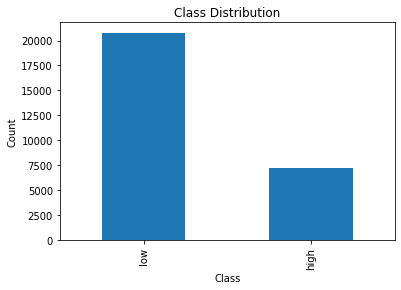

In [3]:
class_counts = df["price_category"].value_counts()
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

### Inspect and Analyze Your Data

Explore your features. Use summary statistics and visualizations to understand how your features are distributed and how they relate to the label. Identify issues such as missing values, outliers, or a feature that is irrelevant or redundant.

Think of the different techniques you have used to inspect and analyze your data in this course. These include using Pandas to apply data filters, using the Pandas `describe()` method to get insight into key statistics for each column, using the Pandas `dtypes` property to inspect the data type of each column, and using Matplotlib and Seaborn to detect outliers and visualize relationships between features and labels. 

Use at least one plot that visualizes a relationship between features and the label.

In [4]:
df.describe()

,host_response_rate,host_acceptance_rate,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,n_host_verifications
count,16179.000000,16909.000000,28022.000000,28022.000000,28022.000000,28022.000000,25104.000000,26668.000000,28022.000000,28022.000000,...,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000,28022.000000
mean,0.906901,0.791953,14.554778,14.554778,2.874491,1.142174,1.329708,1.629556,154.228749,18.689387,...,4.814300,4.808041,4.750393,4.647670,9.581900,5.562986,3.902077,0.048283,1.758325,5.169510
std,0.227282,0.276732,120.721287,120.721287,1.860251,0.421132,0.700726,1.097104,140.816605,25.569151,...,0.438603,0.464585,0.415717,0.518023,32.227523,26.121426,17.972386,0.442459,4.446143,2.028497
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,29.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.010000,1.000000
25%,0.940000,0.680000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,70.000000,2.000000,...,4.810000,4.810000,4.670000,4.550000,1.000000,0.000000,0.000000,0.000000,0.130000,4.000000
50%,1.000000,0.910000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,115.000000,30.000000,...,4.960000,4.970000,4.880000,4.780000,1.000000,1.000000,0.000000,0.000000,0.510000,5.000000
75%,1.000000,1.000000,3.000000,3.000000,4.000000,1.000000,1.000000,2.000000,180.000000,30.000000,...,5.000000,5.000000,5.000000,5.000000,3.000000,1.000000,1.000000,0.000000,1.830000,7.000000
max,1.000000,1.000000,3387.000000,3387.000000,16.000000,8.000000,12.000000,21.000000,1000.000000,1250.000000,...,5.000000,5.000000,5.000000,5.000000,421.000000,308.000000,359.000000,8.000000,141.000000,13.000000


In [5]:
df.dtypes

name                                             object
description                                      object
neighborhood_overview                            object
host_name                                        object
host_location                                    object
host_about                                       object
host_response_rate                              float64
host_acceptance_rate                            float64
host_is_superhost                                  bool
host_listings_count                             float64
host_total_listings_count                       float64
host_has_profile_pic                               bool
host_identity_verified                             bool
neighbourhood_group_cleansed                     object
room_type                                        object
accommodates                                      int64
bathrooms                                       float64
bedrooms                                        

In [6]:
df.isnull().sum()

name                                                5
description                                       570
neighborhood_overview                            9816
host_name                                           0
host_location                                      60
host_about                                      10945
host_response_rate                              11843
host_acceptance_rate                            11113
host_is_superhost                                   0
host_listings_count                                 0
host_total_listings_count                           0
host_has_profile_pic                                0
host_identity_verified                              0
neighbourhood_group_cleansed                        0
room_type                                           0
accommodates                                        0
bathrooms                                           0
bedrooms                                         2918
beds                        

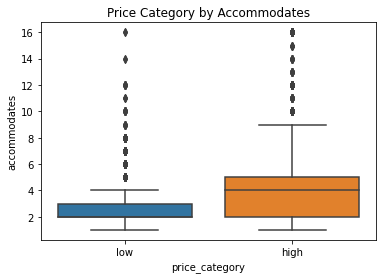

In [7]:
sns.boxplot(x="price_category",
            y="accommodates",
            data=df)

plt.title("Price Category by Accommodates")
plt.show()

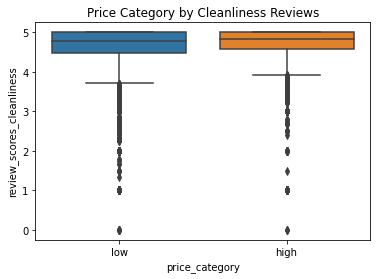

In [8]:
sns.boxplot(x="price_category",
            y="review_scores_cleanliness",
            data=df)

plt.title("Price Category by Cleanliness Reviews")
plt.show()

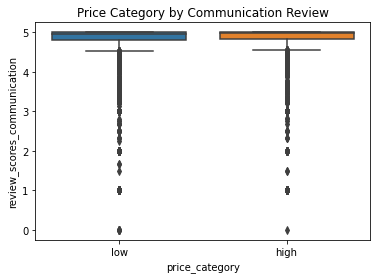

In [9]:
sns.boxplot(x="price_category",
            y="review_scores_communication",
            data=df)

plt.title("Price Category by Communication Review")
plt.show()

### EDA Summary

<b>Task</b>: In the markdown cell below, summarize the key findings from your data exploration. Describe any patterns, anomalies, or data quality issues you identified and explain how those findings may influence your data preparation decisions. For example, your exploration may affect how you handle missing values, address class imbalance, or determine which features to keep or remove.

* Class imbalance: there is a moderate class imbalance in label price_category with low count ~20000 vs. high count ~7500. 
* Data type: a lot of features aren't numerical
* Missing values: several columns that are potentially effective as features have plenty of missing values, such as bedrooms, bed, neighborhood_overview, etc.
* Outlier: there are multiple outliers in all boxplots illustrating individual feature's relationship with the label.

These findings indicate that encoding categorical variables, missing values handling and addressing class imbalance have to be done.


### Ethical Considerations:

Machine learning models can cause harm when they reflect or amplify biases in the data they are trained on. 

<b>Task</b>: In the markdown cell below, answer both of the following questions:

1. What biases or ethical concerns might be present in your dataset? Think about who collected the data, how it was collected, and which groups of people appear in it. Are there features in the dataset that could serve as proxies for protected characteristics like race, gender, or socioeconomic status?
2. Who could be harmed by a model that makes incorrect predictions on this data, and how? Be specific about which groups are most at risk and what the real-world consequences of errors might look like.

1. Since the data is collected from Airbnb listings, it represents only hosts and properties that are available on the platform rather than the entire housing market. This creates potential sampling bias because individuals who do not use Airbnb or areas with fewer Airbnb listings may be underrepresented. The neighborhood related fetaure could servce as proxies for socioeconomic status.
2. Both hosts and customers could be harmed by incorrect predictions in this problem. For hosts, inaccurate price predictions could lead to underpricing that causes potential income loss, or overpricing that makes their listings less competitive. For guests, inaccurate predictions could create limited options with concerns about affordability.

## Part 4: Prepare Your Data

<b>Task</b>: In the code cell below, prepare your data for modeling. The specific steps you take will depend on what you found during your EDA and which model you plan to use. 

<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [10]:
# first, drop all labels that are identifier, irrelevant, redundant, or long string since NLP isn't used
dropped_columns = [
    'name',
    'description',
    'neighborhood_overview',
    'host_name',
    'host_location',
    'host_about',
    'amenities',
    'price',
    'minimum_minimum_nights',
    'maximum_minimum_nights',
    'minimum_maximum_nights',
    'maximum_maximum_nights',
    'minimum_nights_avg_ntm',
    'maximum_nights_avg_ntm',
    'availability_30',
    'availability_60',
    'availability_90',
    'availability_365',
    'host_has_profile_pic',
    'host_identity_verified',
    'host_is_superhost'
]
df.drop(columns=dropped_columns, inplace=True)

In [11]:
df.shape

(28022, 30)

In [12]:
df.isnull().sum().sort_values(ascending=False)

host_response_rate                              11843
host_acceptance_rate                            11113
bedrooms                                         2918
beds                                             1354
n_host_verifications                                0
host_listings_count                                 0
host_total_listings_count                           0
neighbourhood_group_cleansed                        0
room_type                                           0
accommodates                                        0
bathrooms                                           0
minimum_nights                                      0
maximum_nights                                      0
has_availability                                    0
number_of_reviews                                   0
price_category                                      0
number_of_reviews_l30d                              0
review_scores_rating                                0
review_scores_cleanliness   

In [13]:
# fill in null values
numeric_cols = df.select_dtypes(
    include=['int64','float64']
).columns


for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

df.isnull().sum().sort_values(ascending=False)

# all null values filled in 

price_category                                  0
n_host_verifications                            0
host_acceptance_rate                            0
host_listings_count                             0
host_total_listings_count                       0
neighbourhood_group_cleansed                    0
room_type                                       0
accommodates                                    0
bathrooms                                       0
bedrooms                                        0
beds                                            0
minimum_nights                                  0
maximum_nights                                  0
has_availability                                0
number_of_reviews                               0
number_of_reviews_ltm                           0
number_of_reviews_l30d                          0
review_scores_rating                            0
review_scores_cleanliness                       0
review_scores_checkin                           0


In [14]:
# convert boolean values to number
bool_cols = df.select_dtypes(include='bool').columns

df[bool_cols] = df[bool_cols].astype(int)

In [15]:
# convert label
df["price_category"] = df["price_category"].map({
    'low':0,
    'high':1
})

In [16]:
# One Hot Encoder for remaining object columns
to_encode = list(df.select_dtypes(include=['object']).columns)
df[to_encode].nunique()

neighbourhood_group_cleansed    5
room_type                       4
dtype: int64

In [17]:
df_neighbourhood_group = pd.get_dummies(df['neighbourhood_group_cleansed'], prefix='neighborhood_')
df_neighbourhood_group

,neighborhood__Bronx,neighborhood__Brooklyn,neighborhood__Manhattan,neighborhood__Queens,neighborhood__Staten Island
0,0,0,1,0,0
1,0,1,0,0,0
2,0,1,0,0,0
3,0,0,1,0,0
4,0,0,1,0,0
...,...,...,...,...,...
28017,0,0,0,1,0
28018,0,1,0,0,0
28019,0,1,0,0,0
28020,0,1,0,0,0


In [18]:
df_room_type = pd.get_dummies(df['room_type'], prefix='room_type_')
df_room_type

,room_type__Entire home/apt,room_type__Hotel room,room_type__Private room,room_type__Shared room
0,1,0,0,0
1,1,0,0,0
2,1,0,0,0
3,0,0,1,0
4,0,0,1,0
...,...,...,...,...
28017,0,0,1,0
28018,1,0,0,0
28019,0,0,1,0
28020,1,0,0,0


In [19]:
df = pd.concat([df, df_neighbourhood_group, df_room_type], axis=1)

In [20]:
df.drop(columns = 'neighbourhood_group_cleansed', inplace=True)
df.drop(columns = 'room_type', inplace=True)

In [21]:
df.shape

(28022, 37)

### Data Preparation Summary:

<b>Task</b>: In the markdown cell below, document the data preparation steps you took. For each decision, explain why you made it. For example, why did you handle missing values the way you did? Why did you keep or remove certain features? If a preparation step depends on the model you selected (for example, scaling for KNN but not for a decision tree), explain that as well.

1. dropped columns: dropped string data columns because they are either: 1. not available for onehotencoder due to its length 2. not helpful for prediction (like name of the listing)
2. missing values: set int and float data columns as the median of others because data exploration plots indicate that there are a lot of outliers existing in different columns, so using mean may make the data skewed.
3. converted boolean data to type int
4. converted label column to 1 and 0

## Part 5: Train, Test, Evaluate, and Improve a Traditional Machine Learning Model

Now you will train, test and evaluate your model. You will also use model selection techniques to improve your model's performance by identifying the optimal hyperparameter configuration.

<b>Task</b>: In the code cells below, do the following:

1. Create labeled examples from the dataset
2. Create training and test sets out of the labeled examples 
3. Train, test and evaluate your model 
    * You must evaluate your model using accuracy and F1 score. Use `accuracy_score` and `f1_score` from `sklearn.metrics`. For the F1 score, use `average='binary'` since this is a binary classification problem. You will compare your model's performance to that of a neural network later in this capstone. Save the results of your evaluation metrics to variables for later comparison.
    * You may use additional evaluation metrics of your choosing.
4. Perform model selection through grid search cross-validation to identify optimal hyperparameter values for your model
5. Train, test and evaluate a final version of your model using the optimal hyperparameter configuration.
6. Interpret your model's outputs in the context of the business problem. Depending on the model you chose, this might mean:
    * KNN: Describe what your model's performance metrics tell you about its behavior. For example: How does accuracy change as you vary k? What does that suggest about the structure of your data?
    * Decision Tree: print or plot feature importances.
    * Logistic Regression: print or plot the model coefficients.



<b>Note</b>: You can add code cells if needed by going to the <b>Insert</b> menu and clicking on <b>Insert Cell Below</b> in the drop-down menu.

In [22]:
# Create labeled examples from the dataset
y = df["price_category"]
X = df.drop(columns="price_category")

In [26]:
# Create training and test sets out of the labeled examples 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

<b>Decision Tree:<b>

In [27]:
model = DecisionTreeClassifier()
model.fit(X_train, y_train)
pred = model.predict(X_test)
acc = accuracy_score(pred, y_test)
acc

0.7966101694915254

In [28]:
print("running grid search...")
depths = [2, 4, 6, 8, 10, 15, 20]
msl=[1,5,10,20]
mss=[5,10,20]
param_grid={'max_depth':depths, 'min_samples_leaf':msl, 'min_samples_split':mss}
grid = GridSearchCV(model, param_grid, cv=5)
grid_search = grid.fit(X_train, y_train)
print("done")

running grid search...
done


In [29]:
best_c = grid_search.best_estimator_.max_depth
best_msl = grid_search.best_estimator_.min_samples_leaf
best_mss = grid_search.best_estimator_.min_samples_split

print('Best value for depth: {0}'.format(best_c))
print('Best value for minimum samples leaf: {0}'.format(best_msl))
print('Best value for minimum samples split: {0}'.format(best_mss))

print('Accuracy score: {0}'.format(grid_search.best_score_))

Best value for depth: 10
Best value for minimum samples leaf: 10
Best value for minimum samples split: 10
Accuracy score: 0.8293260813026831


In [39]:
dt = DecisionTreeClassifier(max_depth=10, min_samples_leaf=10, min_samples_split=20)
dt.fit(X_train, y_train)
pred = dt.predict(X_test)
dt_acc = accuracy_score(pred, y_test)
dt_f1 = f1_score(y_test, pred)
print(dt_acc, dt_f1)

0.8306868867082962 0.632597754548974


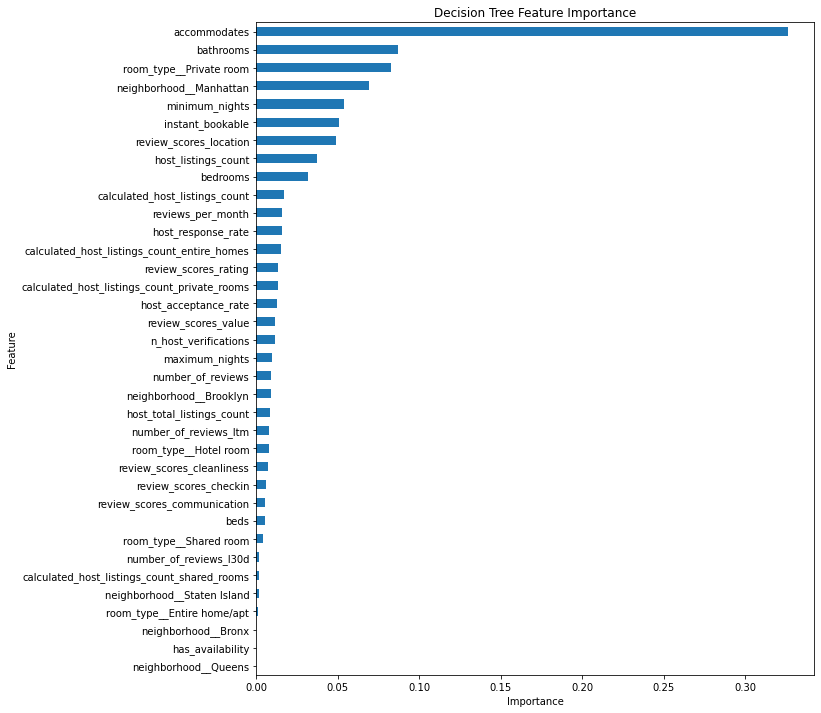

In [40]:
importance = pd.Series(
    dt.feature_importances_,
    index=X_train.columns
)

# Sort from most important to least important
importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10, 12))

importance.sort_values().plot(kind='barh')

plt.title("Decision Tree Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

<b>Logistic Regression:<b>

In [41]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [42]:
# Train, test and evaluate your model
model = LogisticRegression()
model.fit(X_train_scaled, y_train)
pred = model.predict(X_test_scaled)
acc = accuracy_score(pred, y_test)
acc

0.8178412132024978

In [36]:
# Perform model selection through grid search cross-validation (GridSearchCV)
# to identify optimal hyperparameter values for your model
# YOUR CODE HERE
print("running grid search...")
c = [0.01, 0.1, 1, 10, 100]
mi = [100, 500, 1000, 2500, 5000]
param_grid={'C':c, 'max_iter':mi}
grid = GridSearchCV(model, param_grid, cv=5)
grid_search = grid.fit(X_train_scaled, y_train)
print("done")

running grid search...
done


In [43]:
best_c = grid_search.best_estimator_.C
best_mi = grid_search.best_estimator_.max_iter

print('Best value for C: {0}'.format(best_c))
print('Best value for maximum iteration: {0}'.format(best_mi))

print('Accuracy score: {0}'.format(grid_search.best_score_))

Best value for C: 1
Best value for maximum iteration: 100
Accuracy score: 0.8208056682764088


In [44]:
# Train, test and evaluate a final version of your model using the optimal hyperparameter values.
lr = LogisticRegression(C=1, max_iter=100)
lr.fit(X_train_scaled, y_train)
pred = lr.predict(X_test_scaled)
lr_acc = accuracy_score(pred, y_test)
lr_f1 = f1_score(pred, y_test)
print(lr_acc, lr_f1)

0.8178412132024978 0.5796624125154385


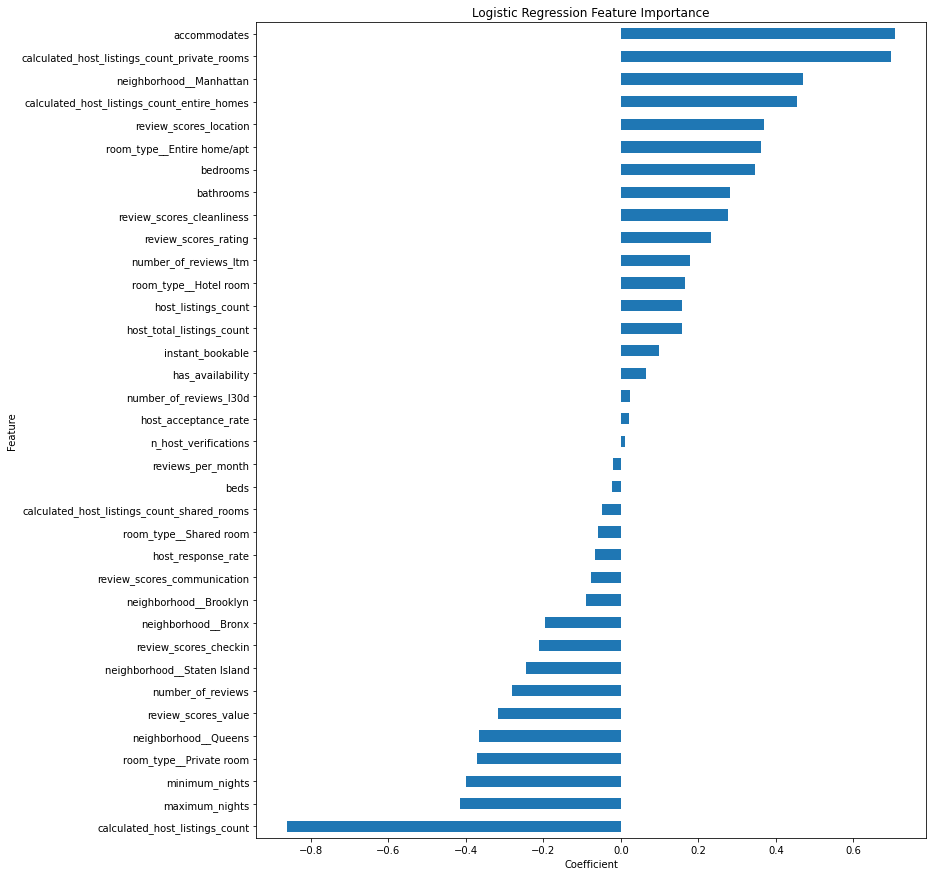

In [45]:
# Interpret your model's outputs 
# TEST feature importance
importance = pd.Series(
    lr.coef_[0],
    index=X_train.columns
)

plt.figure(figsize=(12, 15))  # width, height

importance.sort_values().plot(kind='barh')

plt.title("Logistic Regression Feature Importance")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.show()

### Model Reflection:

<b>Task</b>: In the markdown cell below, answer the following questions:

1. Which model did you choose and why? Reference your problem and data characteristics in your explanation.
2. What did you learn through the model selection process?
3. How do you interpret your model's outputs? What do the predictions or coefficients or feature importances actually mean in the context of your problem?
4. Are there any fairness or ethical concerns with your model? Who might be harmed by incorrect predictions, and are any groups more likely to be affected?

1. I tested two models: Decision Tree / Logistic Regression because my problem is a binary classification task of high priced or low priced where 2 models can have similar performance. 
2. I learned that feature preparation has a significant impact on model performance. Removing irrelevant features such as text descriptions, identifiers, and the original price feature helped prevent noise and target leakage. I also learned that tuning hyperparameters is important for improving accuracy and preventing overfitting.
3. The feature importances show which features contributed most to the model's decisions. For example, features such as accommodates and number of bathrooms have higher importance because they provide strong information for distinguishing between high-priced and low-priced listings. 
4. Location-based features, such as neighborhood, may act as proxies for socioeconomic factors and historical inequalities. A model could unintentionally learn existing patterns in the housing market and make biased predictions for listings in certain areas. Incorrect predictions could harm hosts by causing them to set inappropriate prices, potentially reducing income for smaller or less experienced hosts. Guests could also be affected if inaccurate predictions create misleading expectations about affordability. 

---
## ✔️ Unit 5 Checkpoint

**Stop here.** If you have completed Parts 1 through 5, you are done with the Unit 5 portion of this capstone.

Parts 6 and 7 require you to train and evaluate a neural network. You will learn about neural networks in the Unit 6 asynchronous content. Do not start Part 6 until you have completed that material and your lab facilitator has directed you to continue. Do not submit your work for grading until you complete Parts 6 and 7.

Make sure your notebook is saved before you close it.

---
## Part 6: Train, Test, Evaluate and Improve a Neural Network

> **⚠️ Before you write any code in Part 6, do this first.**
> 
> Your notebook does not retain variables between sessions. All of your variables and everything else need to be restored to memory before any code below will work.
> 
> Go to **Kernel > Restart & Run All** to re-run Parts 1 through 5, then scroll back here to continue. If you skip this step, you will see a `NameError` on the first code cell below.

Now you will apply a neural network to the same problem and dataset. You will use Keras to build a feedforward neural network for binary classification.

The scaffolding below will walk you through the steps. Where you see a **Task**, fill in the code. Where you see a **Decision**, you are making an independent choice about your architecture or training process. For each decision, add a comment explaining what you chose and why.


### Prepare Your Data for the Neural Network

Neural networks require all input features to be numeric and scaled. If your features are on very different scales (for example, one feature ranges from 0 to 90 and another from 0 to 99999), the model may train less effectively and have difficulty learning meaningful patterns from the data.

Before training your network, create scaled versions of your training and test data. Use `StandardScaler()` from `sklearn.preprocessing` to standardize your features: 

<b>Task</b>: Complete the code cell below to fit the scaler on your training data, then transform both training and test sets. Save the results to new variables (for example, `X_train_scaled` and `X_test_scaled`) so your original data remains available for reference.

**Note:** Use your scaled data for all neural network steps below.

In [46]:
# Scale your data for the neural network

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform the training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler to transform the test data
X_test_scaled = scaler.transform(X_test)

### Step 1: Define Your Model Architecture

You will use the Keras `Sequential` class to build your network. Your network should have:

- An input layer with the correct shape for your data
- At least two hidden layers using the `Dense` class
- An output layer appropriate for binary classification

<b>Task:</b> Create a `Sequential` model object and name it `nn_model`. Then construct and add each layer.

**Decision:** How many hidden layers will you use? How many units in each? What activation function will you use for the hidden layers? Add a comment explaining your choices.

In [47]:
# Get the number of features in your training data
n_features = X_train_scaled.shape[1]

# Create the neural network model
nn_model = keras.Sequential()

# Create the input layer and add the input layer to the 'nn_model' object
input_layer = keras.layers.InputLayer(input_shape=(n_features,),name='input')

# Create the hidden layers and add the hidden layers to the 'nn_model' object
# Decision: 3 layers, 128-64-32.
# 128-64-32 provides enough capacity to learn complex relationships without being unnecessarily large. It's a balance between model expressiveness and the risk of overfitting.
hidden_layer_1 = keras.layers.Dense(units=128, activation='relu', name='hl_1')
nn_model.add(hidden_layer_1)
batch_norm_1 = keras.layers.BatchNormalization(name='bn_1')
nn_model.add(batch_norm_1)

hidden_layer_2 = keras.layers.Dense(units=64, activation='relu', name='hl_2')
nn_model.add(hidden_layer_2)
batch_norm_2 = keras.layers.BatchNormalization(name='bn_2')
nn_model.add(batch_norm_2)

hidden_layer_3 = keras.layers.Dense(units=32, activation='relu', name='hl_3')
nn_model.add(hidden_layer_3)

# Create the output layer and add the output layer to the 'nn_model' object
# Use the correct number of units and activation function for binary classification
output_layer = keras.layers.Dense(units=1, activation='sigmoid', name='output') 
nn_model.add(output_layer)

# Print a summary of your model
# nn_model.summary()

### Step 2:  Define the Optimization Function

<b>Task:</b> In the code cell below, create an optimizer object. Use stochastic gradient descent (SGD) with a learning rate of your choosing.

**Decision:** What learning rate will you use? Add a comment explaining your choice.

In [48]:
# Decision: What learning rate will you use? Add a comment explaining your decision.

sgd_optimizer = keras.optimizers.SGD(learning_rate=0.001)

### Step 3: Define the Loss Function

<b>Task:</b> In the code cell below, create a binary cross entropy loss function using `keras.losses.BinaryCrossentropy()`. Use  the parameter `from_logits=False`. 

In [49]:
loss_fn = keras.losses.BinaryCrossentropy(from_logits=False)

### Step 4: Compile the Model

<b>Task:</b> In the code cell below, package the network architecture with the optimizer and the loss function using the `compile()` method. Use the `accuracy` evaluation metric.

In [50]:
# YOUR CODE HERE
nn_model.compile(optimizer=sgd_optimizer, loss=loss_fn, metrics=['accuracy'])

### Step 5: Fit the Model to the Training Data

We will define our own callback class to output information from our model while it is training. Make sure you execute the code cell below so that it can be used in subsequent cells.

In [51]:
class ProgBarLoggerNEpochs(keras.callbacks.Callback):
    
    def __init__(self, num_epochs: int, every_n: int = 50):
        self.num_epochs = num_epochs
        self.every_n = every_n
    
    def on_epoch_end(self, epoch, logs=None):
        if (epoch + 1) % self.every_n == 0:
            s = 'Epoch [{}/ {}]'.format(epoch + 1, self.num_epochs)
            logs_s = ['{}: {:.4f}'.format(k.capitalize(), v)
                      for k, v in logs.items()]
            s_list = [s] + logs_s
            print(', '.join(s_list))


<b>Task:</b> Use the `fit()` method to fit your model to the training data. Save the result to variable `history.`

Use the `validation_split` parameter to reserve a portion of your training data for validation during training (a common choice is `validation_split=0.2`). After each epoch, the model is evaluated on this validation data, allowing you to monitor how well the model generalizes and helping you detect overfitting.

Also, use the the logger class defined above to track training progress.

**Decision:** How many epochs will you train for? Add a comment explaining your choice.

**Note:** This may take a while to run.

In [52]:
from sklearn.utils import class_weight


weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(weights))

print(class_weights)

{0: 0.6740738513350975, 1: 1.9361720504404907}


In [53]:
# Decision: 200 epochs. 
# When I tested with 100 epochs, loss values doesn't show sign of overfitting. With 200 epochs, the model stops right before overfitting.

t0 = time.time() # start time

num_epochs = 200

history = nn_model.fit(
    X_train_scaled,
    y_train,
    epochs=num_epochs,
    validation_split=0.2,
    verbose=0, # disable the default progress bar
    class_weight=class_weights,
    callbacks=[ProgBarLoggerNEpochs(num_epochs, every_n=10)],
)

t1 = time.time() # stop time

print('Elapsed time: %.2fs' % (t1-t0))

Epoch [10/ 200], Loss: 0.4607, Accuracy: 0.7659, Val_loss: 0.4531, Val_accuracy: 0.7736
Epoch [20/ 200], Loss: 0.4401, Accuracy: 0.7817, Val_loss: 0.4358, Val_accuracy: 0.7852
Epoch [30/ 200], Loss: 0.4274, Accuracy: 0.7872, Val_loss: 0.4244, Val_accuracy: 0.7935
Epoch [40/ 200], Loss: 0.4222, Accuracy: 0.7908, Val_loss: 0.4239, Val_accuracy: 0.7924
Epoch [50/ 200], Loss: 0.4107, Accuracy: 0.7965, Val_loss: 0.4132, Val_accuracy: 0.7991
Epoch [60/ 200], Loss: 0.4089, Accuracy: 0.7946, Val_loss: 0.4124, Val_accuracy: 0.8015
Epoch [70/ 200], Loss: 0.4028, Accuracy: 0.7997, Val_loss: 0.4114, Val_accuracy: 0.8026
Epoch [80/ 200], Loss: 0.3975, Accuracy: 0.8053, Val_loss: 0.4117, Val_accuracy: 0.8033
Epoch [90/ 200], Loss: 0.3950, Accuracy: 0.8023, Val_loss: 0.4120, Val_accuracy: 0.8022
Epoch [100/ 200], Loss: 0.3894, Accuracy: 0.8086, Val_loss: 0.4075, Val_accuracy: 0.8031
Epoch [110/ 200], Loss: 0.3885, Accuracy: 0.8070, Val_loss: 0.4036, Val_accuracy: 0.8071
Epoch [120/ 200], Loss: 0.3852

### Step 6: Visualize Training Performance

<b>Task:</b>  

Create two plots to visualize the model's performance over time:
1. Training loss and validation loss over epochs, on the same axes.
2. Training accuracy and validation accuracy over epochs, on the same axes.

Label your axes and include a legend.

Use the `history` object returned by `fit()` to obtain this information. 



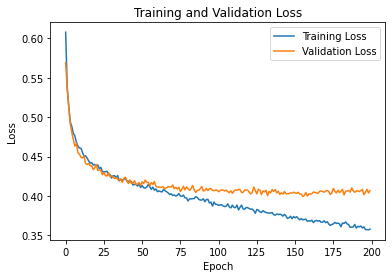

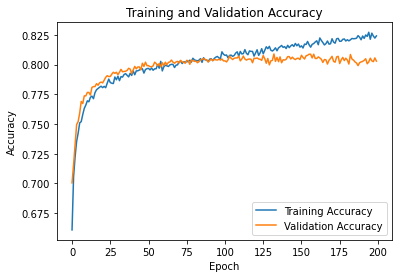

In [54]:
# Plot training loss and validation loss over epochs
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

# Plot training accuracy and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()

### Step 7: Evaluate the Model's Performance on the Test Set

<b>Task:</b> Use your neural network to generate predictions on the test set and evaluate its performance using accuracy and F1 score. Use `nn_model.predict()` to generate predictions. Since `nn_model.predict()` returns probabilities, apply a threshold of 0.5 to convert probabilities into binary class predictions before computing your metrics. Save your accuracy and F1 score results to clearly named variables so you can compare them to the results from your previous model. Print the results.

In [56]:
# Generate predictions from your neural network using your scaled test data
# nn_model.predict() returns probabilities — apply a threshold of 0.5 to get class labels

y_pred_prob = nn_model.predict(X_test_scaled)

# Convert probabilities to binary predictions
y_pred = (y_pred_prob >= 0.5).astype(int)

In [58]:
# Compute accuracy and F1 score for the neural network and print the results

# Compute accuracy and F1 score
nn_acc = accuracy_score(y_test, y_pred)
nn_f1 = f1_score(y_test, y_pred)

# Print results
print(f"Neural Network Accuracy: {nn_acc:.4f}")
print(f"Neural Network F1 Score: {nn_f1:.4f}")

Neural Network Accuracy: 0.8020
Neural Network F1 Score: 0.6839


#### Neural Network Reflection:

<b>Task:</b> In the markdown cell below, answer the following questions:

1. Walk through the architecture decisions you made: number of layers, number of units, activation functions, learning rate, and number of epochs. Why did you make each of those choices?
2. What did your training curves tell you? Did you see any signs of overfitting or underfitting?
3. How did your neural network perform on the test set? Report your accuracy and F1 score here and note whether the result surprised you given what your training curves showed.

1. I used a neural network with three hidden layers (128, 64, and 32 units) to capture complex patterns while gradually reducing the learned features. ReLU activation was used for hidden layers because it introduces non-linearity and supports efficient training. The output layer uses a sigmoid activation function since this is a binary classification problem.
2. The training curves showed consistent improvement, with training loss decreasing to 0.3548 and validation loss decreasing to 0.4055. Training accuracy reached ~82.7% and validation accuracy reached ~80.2%. The small gap between training and validation performance suggests limited overfitting, and the improving curves indicate the model was not underfitting.
3. The neural network achieved 80.52% accuracy and an F1 score of 0.6846 on the test set. The result was consistent with the validation accuracy, showing that the model generalized well. The lower F1 score compared to accuracy is expected due to the class imbalance in the dataset.

## Part 7: Compare Your Models and Reflect

You have now applied two different approaches to the same problem. In this final section, you will put those results side by side and reflect on what you learned.

###  Results Summary

<b>Task:</b> In the code cell below, create a summary table using a Pandas DataFrame that displays each evaluation metric for both models side by side. Use the variables you created for the accuracy and F1 score metrics. The table should make it easy to compare performance at a glance across every metric you computed.

In [59]:
# Build a side-by-side comparison of your two models using the metric variables you created.

results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1 Score'],
    'Logistic Regression Model': [lr_acc, lr_f1],
    'Neural Network': [nn_acc, nn_f1]
})
print(results.to_string(index=False))

   Metric  Logistic Regression Model  Neural Network
 Accuracy                   0.817841        0.801963
 F1 Score                   0.579662        0.683941


### Comparative Analysis

<b>Task:</b> In the markdown cell below, write a comparative analysis that addresses the following. 

1. **Performance comparison.** How did the two models perform relative to each other? Which metrics improved, which stayed the same, and which got worse?

2. **Was the added complexity worth it?** Neural networks are more complex to build, tune, and interpret. Given the performance difference you observed, do you think the neural network justified that added complexity for this problem?

3. **Recommendation.** If you were presenting this work to your company and their client as described in the business brief, which model would you recommend deploying and why? Consider not just performance but also interpretability, training time, and what the costs of different types of errors look like for that specific client.

4. **What you would do next.** If you had more time, what would you try to improve your results? This could include trying different architectures, additional preprocessing steps, different features, or techniques to address class imbalance. Be specific.

1. (I chose logistic regression to be my first model) The logistic regression model achieved a higher accuracy (81.78%) compared to the neural network (80.20%), while the neural network achieved a higher F1 score (0.6839 vs. 0.5797). This indicates that although logistic regression performed slightly better in overall accuracy, the neural network was better at identifying the minority class and balancing precision and recall. The higher F1 score suggests that the neural network handled the class imbalance more effectively.
2. For this problem, I do not think the added complexity of the neural network was fully justified. Although it improved the F1 score, the overall accuracy was slightly lower, and the neural network required more time to build, tune, and interpret. Since the performance improvement was limited, a simpler model may provide a better balance between performance and maintainability.
3. I would recommend deploying the logistic regression model for this client because it provides competitive accuracy while being faster to train, easier to interpret, and simpler to maintain. However, if the cost of missing minority-class examples is high, the neural network could be considered because its higher F1 score indicates better detection of the minority class.
4. Since I've already done a lot of work with feature engineering for logistic regression and hyperparam tuning, if I have more time, I would try improving my neural networks by trying more techniques that improve generalization, with the goal of improving its accuracy so deploying neural networks can be justified by the accuracy. However, I may still try tuning more hyperparam for the logistic regression model to see where its maximum performance is at. 

---
## AI Use Attestation

Reflect honestly on how you used AI tools during this capstone. You are expected to have used AI somewhere in your workflow, and your reflection on that use is what will be evaluated: How clearly you describe your choices, how you verified your work, and what you learned from the process. If you chose not to use AI, explain why. Answer each question in the markdown cell below.

1. Where and at what stages of this capstone did you use AI tools, for example, Claude during brainstorming, coding, or debugging? If you chose not to use AI, explain why.
2. Identify one part of the capstone that required the most effort or thought. What made it challenging, and how did you work through it, with AI or without AI? If you used AI at this point, feel free to share a prompt that worked well or one that did not land the way you expected.
3. How did you verify that your work was correct? What did you look for to catch a mistake, whether it came from AI output or your own reasoning?
4. What is one thing you would do differently next time, either in how you approached the capstone or in how you used AI during it?

1. I used AI tools mainly during design decisions and debugging stages of this capstone. I used AI to troubleshoot code errors, and suggest possible improvements during model training. For example, I used AI when debugging issues with my neural network implementation where it found that I was not using scaled data. I also used its suggestions for model design (like how many layers, nodes for neural network) as guidance but made sure to understand and implement the final solutions myself.
2. The most challenging part was improving the neural network model. Unlike simpler models, neural networks required decisions about architecture, number of layers, number of units, learning rate, and handling class imbalance. I worked through this by experimenting with different configurations, comparing validation results, and researching the effects of different techniques such as feature scaling and class weighting. AI helped me understand why certain approaches worked, but I verified changes by running experiments and comparing metrics.
3. Since the dataset had class imbalance, I compared F1 scores in addition to accuracy to understand how well the models handled the minority class. I also reviewed training and validation curves to check for overfitting or underfitting and manually checked whether the code behavior matched the expected results.
4. Next time, I would plan my experiments more systematically by creating a clearer comparison table for different models and hyperparameters earlier in the process. 